Mengimpor semua library yang dibutuhkan, mulai dari OpenCV untuk pemrosesan gambar, NumPy dan Pandas untuk manipulasi data, Matplotlib dan Seaborn untuk visualisasi, scikit-learn untuk model klasifikasi dan evaluasi, serta skimage dan scipy untuk ekstraksi fitur GLCM.

In [1]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)

In [2]:
data = []
labels = []
file_name = []

dataset_path = "dataset/"

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(full_path):
        continue  # Lewati jika bukan folder

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

In [3]:
def baseline(img):
    if len(img.shape) == 3:  # kalau RGB/BGR
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    img = cv.resize(img, (128, 128))
    return img

# apply ke semua data
dataPreprocessed = [baseline(img) for img in data]

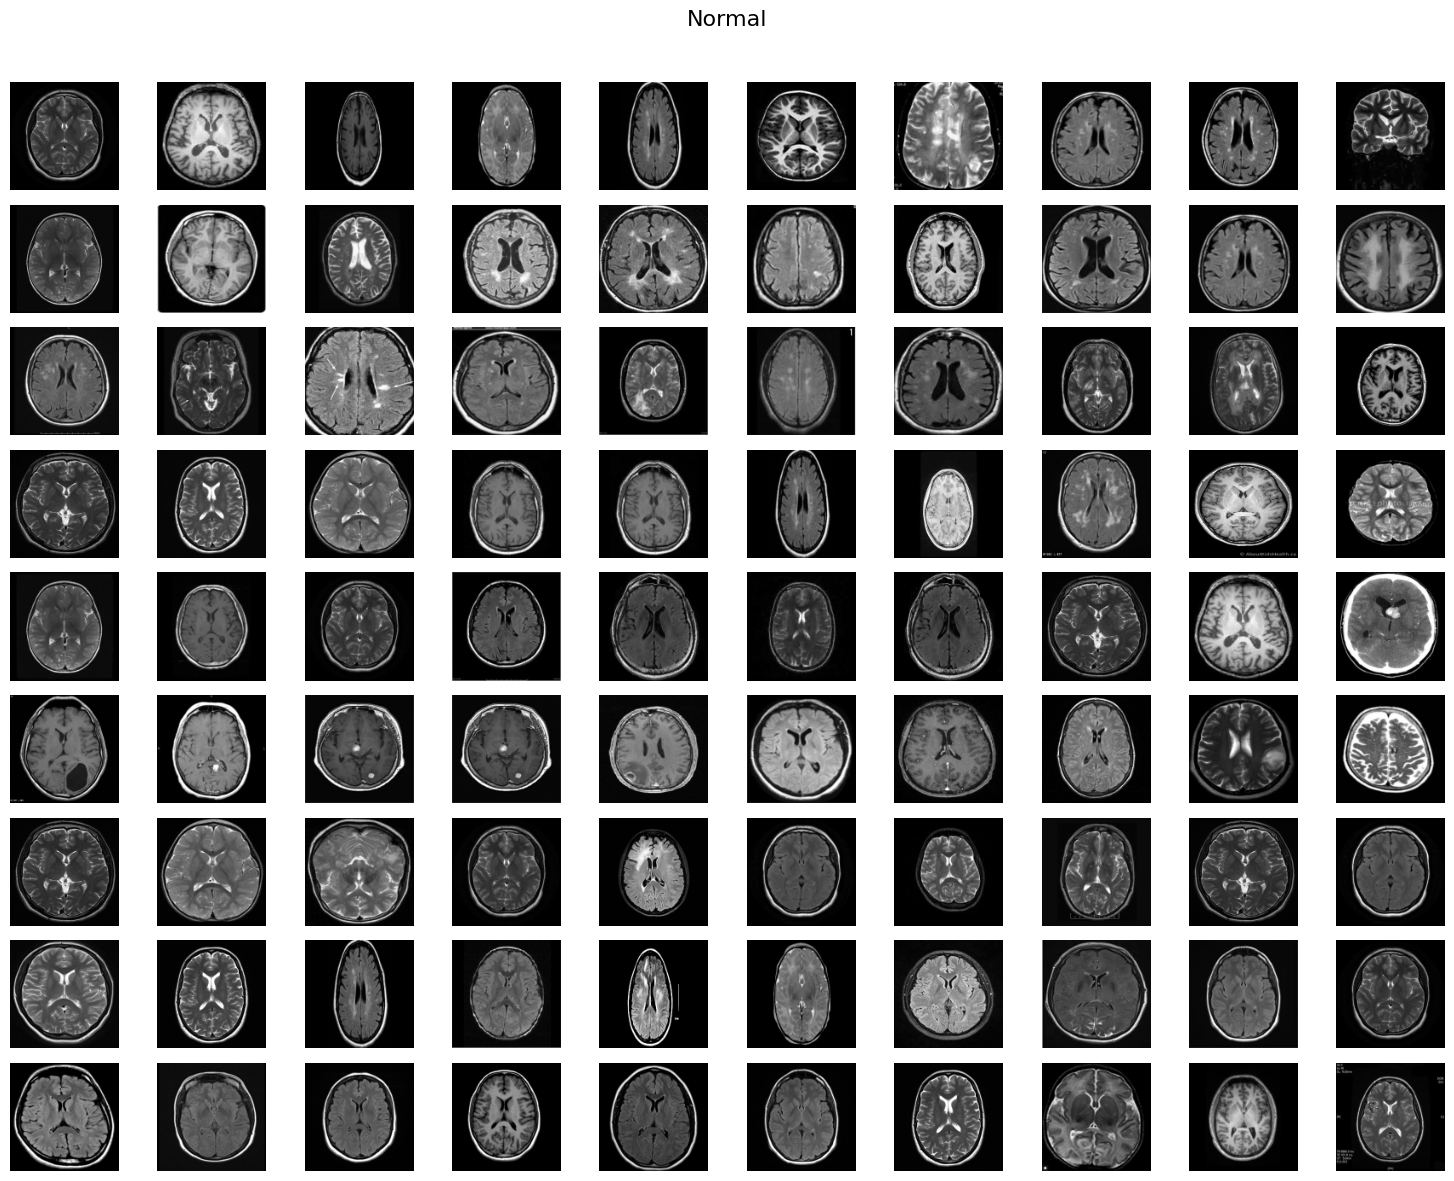

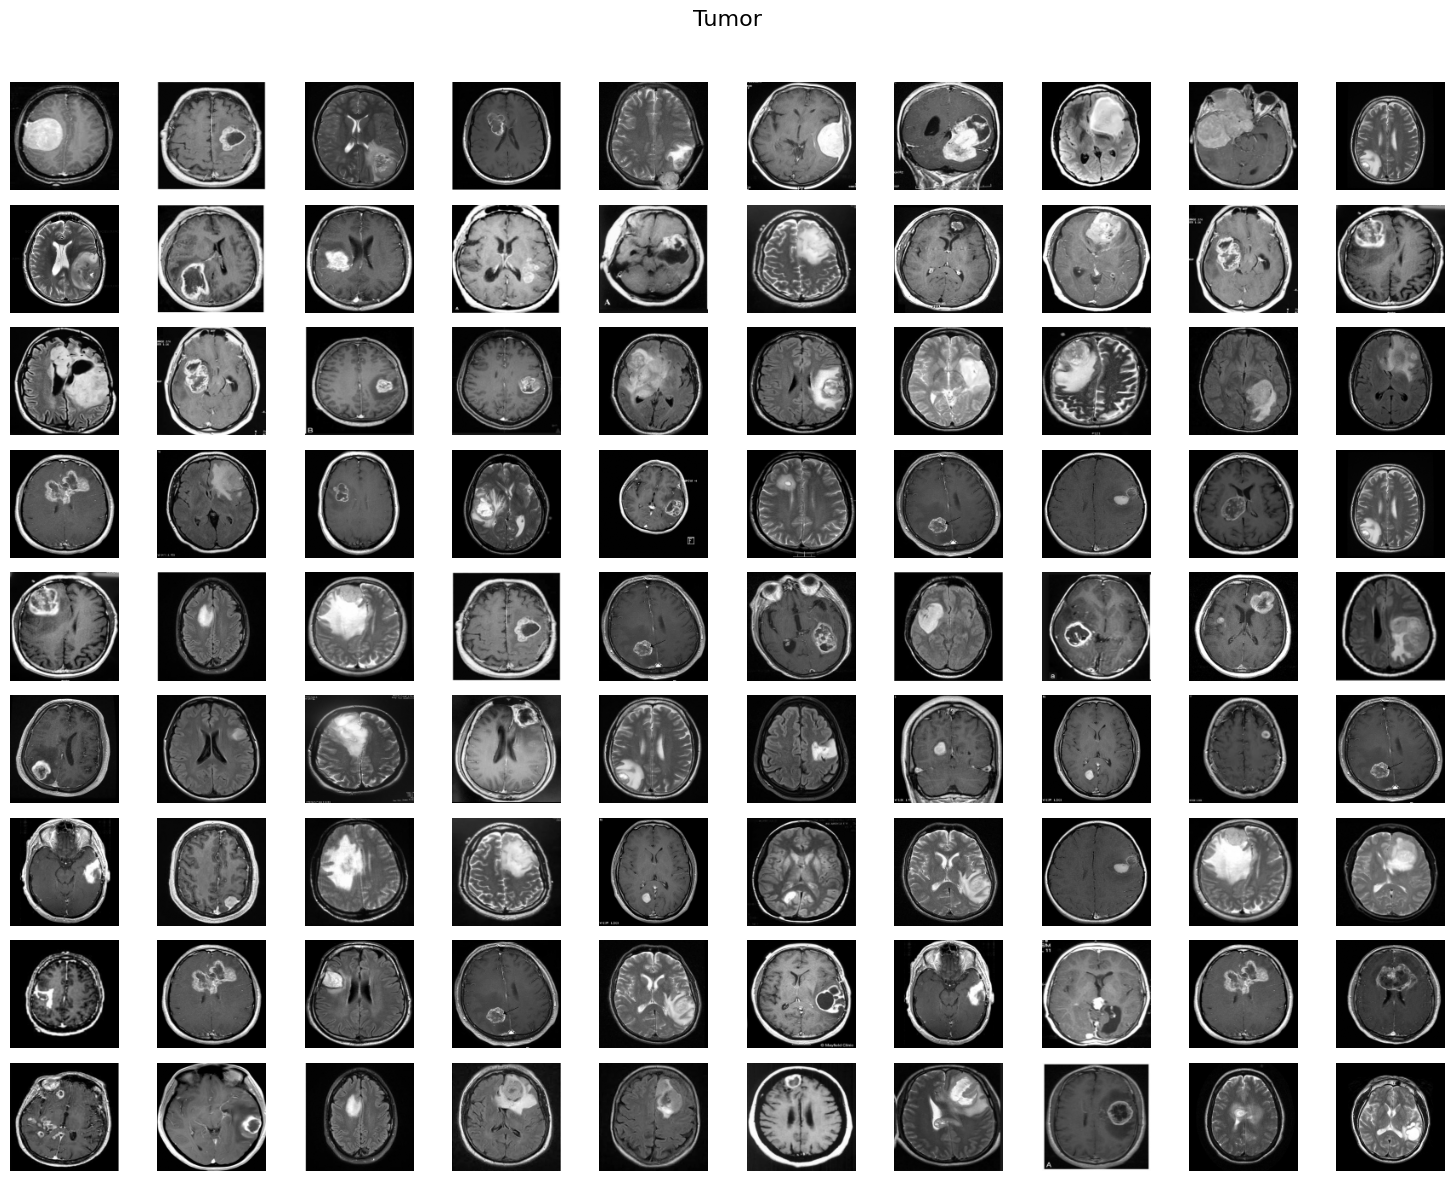

In [4]:
# ambil index berdasarkan label
normal_indx = [i for i, l in enumerate(labels) if l.lower() == "normal"]
tumor_indx = [i for i, l in enumerate(labels) if l.lower() == "tumor"]

# ambil maksimal 90
normal_indx = normal_indx[:90]
tumor_indx = tumor_indx[:90]


def show_images(idxs, title):
    fig, axs = plt.subplots(9, 10, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)

    for k in range(len(idxs)):
        row = k // 10
        col = k % 10
        axs[row][col].imshow(dataPreprocessed[idxs[k]], cmap='gray')
        axs[row][col].axis('off')

    # matikan subplot kosong
    for k in range(len(idxs), 90):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# tampilkan
show_images(normal_indx, "Normal")
show_images(tumor_indx, "Tumor")

In [5]:
from collections import Counter

# -----------------------------
# 1. Menampilkan Jumlah Data
print("Jumlah total gambar:", len(data))
print("Jumlah kelas:", len(np.unique(labels)))
print("Distribusi per kelas:", Counter(labels))

Jumlah total gambar: 196
Jumlah kelas: 2
Distribusi per kelas: Counter({np.str_('normal'): 98, np.str_('tumor'): 98})


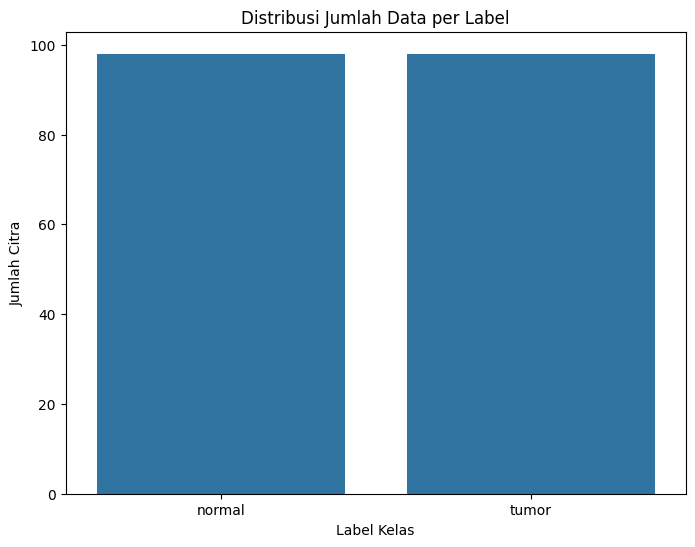

Total jumlah citra dalam dataset: 196
Total jumlah label dalam dataset: 196
Jumlah kelas unik: 2

Jumlah citra per kelas:
normal    98
tumor     98
Name: count, dtype: int64


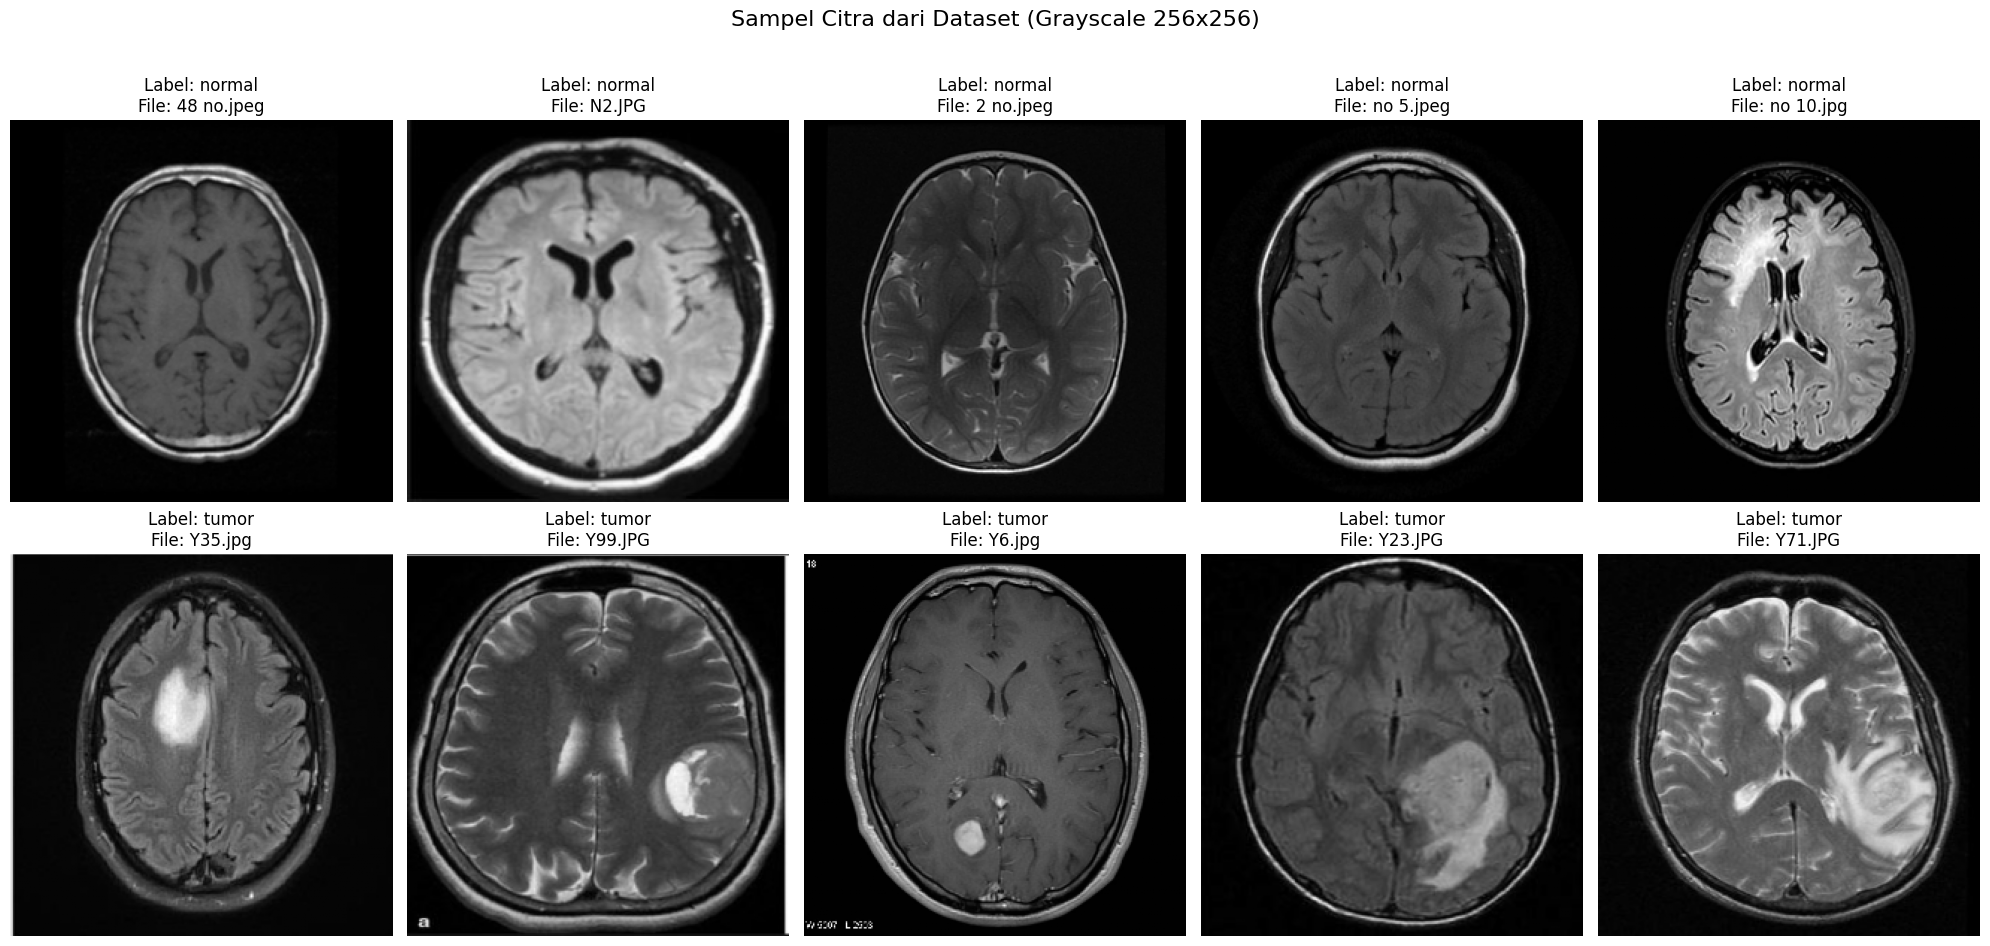

In [6]:
# Mengubah list labels menjadi pandas Series untuk memudahkan penghitungan
label_series = pd.Series(labels)

# Menghitung jumlah kemunculan setiap label
label_counts = label_series.value_counts()

# Membuat diagram batang
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribusi Jumlah Data per Label')
plt.xlabel('Label Kelas')
plt.ylabel('Jumlah Citra')
plt.show()

# Menampilkan jumlah data dan label secara keseluruhan
print(f"Total jumlah citra dalam dataset: {len(data)}")
print(f"Total jumlah label dalam dataset: {len(labels)}")
print(f"Jumlah kelas unik: {len(label_counts)}")
print("\nJumlah citra per kelas:")
print(label_counts)

# Mendapatkan indeks untuk kelas 'normal' dan 'tumor'
normal_indices = np.where(labels == 'normal')[0]
tumor_indices = np.where(labels == 'tumor')[0]

# Mengambil 5 sampel acak jika jumlahnya lebih dari 5, atau semua sampel jika kurang dari 5
num_samples_to_show = 5
if len(normal_indices) >= num_samples_to_show:
    sample_normal_indices = np.random.choice(normal_indices, num_samples_to_show, replace=False)
else:
    sample_normal_indices = normal_indices

if len(tumor_indices) >= num_samples_to_show:
    sample_tumor_indices = np.random.choice(tumor_indices, num_samples_to_show, replace=False)
else:
    sample_tumor_indices = tumor_indices
    
# Menggabungkan indeks sampel
sample_indices = np.concatenate((sample_normal_indices, sample_tumor_indices))

# Menampilkan citra sampel
plt.figure(figsize=(20, 10))
plt.suptitle('Sampel Citra dari Dataset (Grayscale 256x256)', fontsize=16)
for i, index in enumerate(sample_indices):
    plt.subplot(2, num_samples_to_show, i + 1)
    plt.imshow(data[index], cmap='gray') # Menampilkan citra grayscale
    plt.title(f"Label: {labels[index]}\nFile: {file_name[index]}")
    plt.axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Menyesuaikan layout agar supertitle tidak tumpang tindih
plt.show()

In [7]:
def hitung_histogram(gambar):

    img_arr = np.array(gambar).astype(float)

    # grayscale luminance
    if len(img_arr.shape) == 3:
        img_arr = (
            0.299 * img_arr[:,:,0] +
            0.587 * img_arr[:,:,1] +
            0.114 * img_arr[:,:,2]
        )

    if img_arr.max() <= 1.1:
        img_arr = img_arr * 255

    piksel_flat = img_arr.flatten()

    histogram = [0] * 256

    for p in piksel_flat:

        p = int(round(p))

        if 0 <= p <= 255:
            histogram[p] += 1

    return histogram

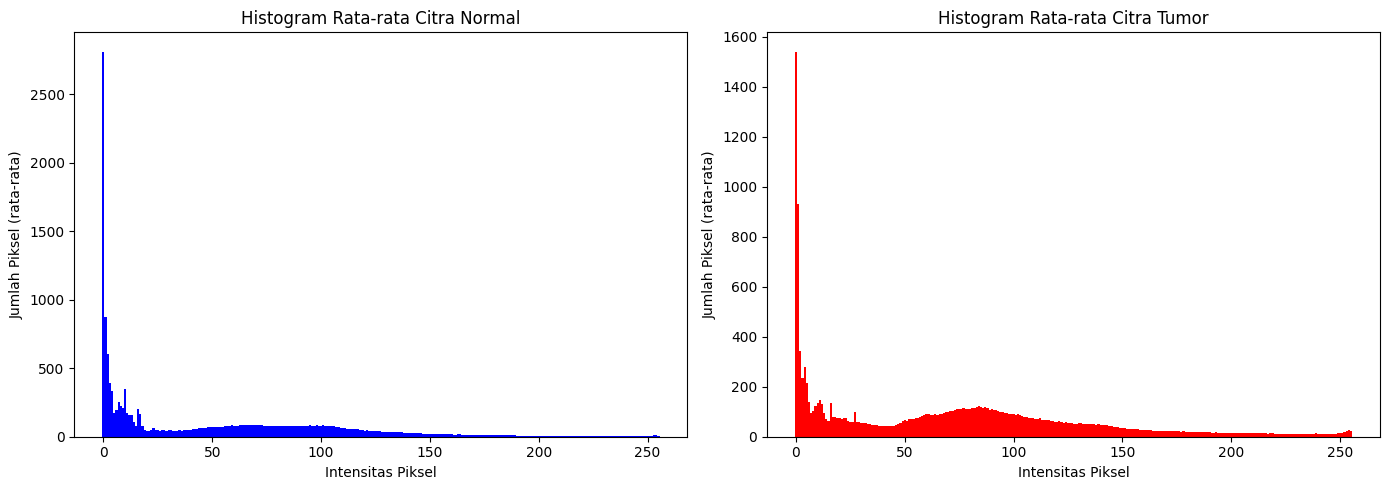

In [8]:
# Ambil gambar dari dataPreprocessed berdasarkan index
imgs_normal = [dataPreprocessed[i] for i in normal_indx]
imgs_tumor  = [dataPreprocessed[i] for i in tumor_indx]

# Gabungkan semua gambar normal & tumor menjadi satu array lalu hitung histogram rata-rata
def rata_rata_histogram(gambar_list):
    total = [0] * 256
    for img in gambar_list:
        h = hitung_histogram(img)
        for k in range(256):
            total[k] += h[k]
    # bagi dengan jumlah gambar agar jadi rata-rata
    n = len(gambar_list)
    return [v / n for v in total]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(np.arange(256), rata_rata_histogram(imgs_normal), color='blue', width=1)
axes[0].set_title('Histogram Rata-rata Citra Normal')
axes[0].set_xlabel('Intensitas Piksel')
axes[0].set_ylabel('Jumlah Piksel (rata-rata)')

axes[1].bar(np.arange(256), rata_rata_histogram(imgs_tumor), color='red', width=1)
axes[1].set_title('Histogram Rata-rata Citra Tumor')
axes[1].set_xlabel('Intensitas Piksel')
axes[1].set_ylabel('Jumlah Piksel (rata-rata)')

plt.tight_layout()
plt.show()

In [9]:
# Thresholding: mengubah citra grayscale menjadi citra biner (0 atau 255)
def thresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if img[i, j] > batas:
                canvas[i, j] = 255
            else:
                canvas[i, j] = 0
    return canvas


# Dilasi: memperluas area objek putih pada citra biner
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0
    return hasil.astype(np.uint8)


# Erosi: menipiskan area objek putih pada citra biner
def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil


# Closing: dilasi diikuti erosi
def closing(image, kernel):
    return erosi(dilasi(image, kernel), kernel)




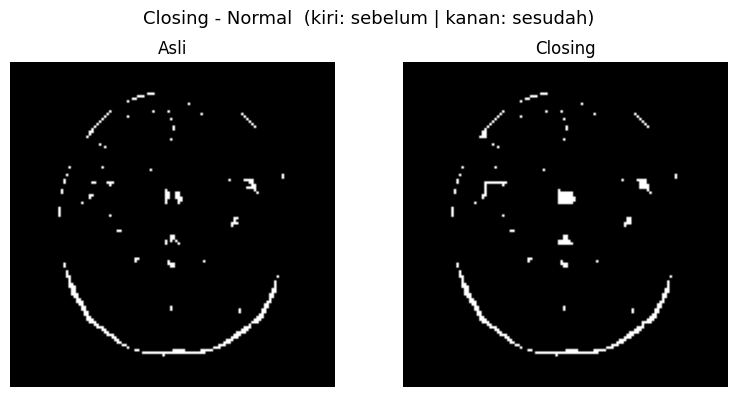

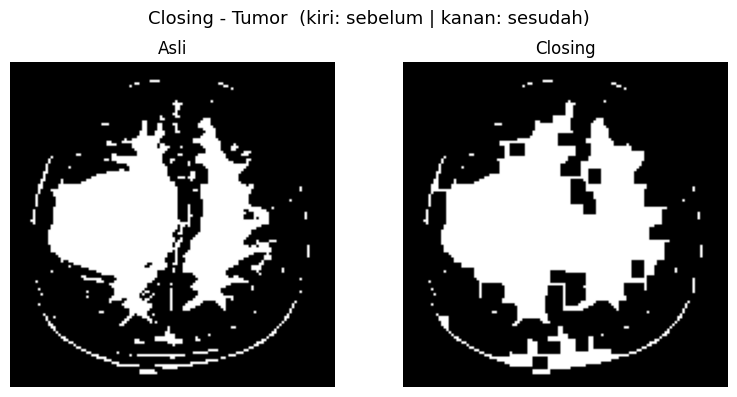

In [10]:
kernel = np.ones((5, 5), dtype=np.uint8)  # kernel 5x5

def tampilkan_closing(indx_list, judul_kelas):
    # Ambil hanya 1 gambar sample dari indx_list
    data_idx = indx_list[0]

    img = dataPreprocessed[data_idx]
    biner = thresholding(img, batas=127)
    hasil = closing(biner, kernel)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f"Closing - {judul_kelas}  (kiri: sebelum | kanan: sesudah)", fontsize=13)

    axes[0].imshow(biner, cmap='gray')
    axes[0].set_title("Asli")
    axes[0].axis('off')

    axes[1].imshow(hasil, cmap='gray')
    axes[1].set_title("Closing")
    axes[1].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

tampilkan_closing(normal_indx, "Normal")
tampilkan_closing(tumor_indx, "Tumor")


In [11]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [12]:
def correlation(matriks):
  	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [13]:
# Fungsi ekstraksi fitur untuk list citra
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0

        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

def2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan1')
display(def2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,296.029281,0.880797,0.229585,0.445117,7.395669,0.052709,6.046517,percobaan1
1,121.094919,0.961494,0.214811,0.369847,6.409018,0.046144,6.841184,percobaan1
2,480.232160,0.818744,0.658878,0.708494,6.933071,0.434120,3.357744,percobaan1
3,329.884719,0.938436,0.536811,0.608607,6.931718,0.288166,4.387046,percobaan1
4,681.151083,0.845466,0.404274,0.587385,9.930856,0.163437,4.835265,percobaan1
...,...,...,...,...,...,...,...,...
191,261.362697,0.933623,0.250507,0.501766,7.082308,0.062754,5.899099,percobaan1
192,471.107406,0.859188,0.341521,0.464327,9.823327,0.116637,5.979240,percobaan1
193,192.315637,0.967445,0.035051,0.233675,7.830770,0.001229,8.001797,percobaan1
194,272.200726,0.934845,0.235942,0.387385,7.761257,0.055669,6.573744,percobaan1


In [14]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [15]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [16]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [17]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [18]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [19]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [20]:
for i in range(len(data)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [21]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [22]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

In [23]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

In [24]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1 no.jpeg,normal,296.029281,463.843884,265.992372,470.407589,0.445117,0.422199,0.455595,0.420137,...,0.052837,0.048164,0.229585,0.219212,0.229863,0.219464,0.880797,0.813621,0.892892,0.810983
1,10 no.jpg,normal,121.094919,204.082460,105.381090,202.514601,0.369847,0.327008,0.372664,0.330416,...,0.046737,0.042422,0.214811,0.205676,0.216187,0.205966,0.961494,0.934904,0.966497,0.935405
2,11 no.jpg,normal,480.232160,582.150784,166.802411,565.291587,0.708494,0.699807,0.737145,0.700218,...,0.438370,0.428559,0.658878,0.653969,0.662095,0.654644,0.818744,0.781559,0.937044,0.787885
3,12 no.jpg,normal,329.884719,429.666687,165.836983,410.766942,0.608607,0.596211,0.631248,0.594606,...,0.292216,0.283320,0.536811,0.532221,0.540570,0.532278,0.938436,0.920072,0.969053,0.923587
4,13 no.jpg,normal,681.151083,797.612127,202.169291,797.055862,0.587385,0.583835,0.640628,0.583791,...,0.177996,0.162635,0.404274,0.403368,0.421896,0.403281,0.845466,0.819138,0.953953,0.819265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,Y95.jpg,tumor,261.362697,379.033232,236.341658,401.811272,0.501766,0.452430,0.516374,0.453442,...,0.063003,0.055337,0.250507,0.235887,0.251003,0.235239,0.933623,0.904190,0.939978,0.898432
192,Y96.jpg,tumor,471.107406,724.433133,397.094857,694.501333,0.464327,0.439189,0.467655,0.438084,...,0.116474,0.110382,0.341521,0.332060,0.341283,0.332238,0.859188,0.783542,0.881307,0.792486
193,Y97.JPG,tumor,192.315637,351.086180,199.053273,381.855540,0.233675,0.175058,0.229586,0.169180,...,0.001195,0.000949,0.035051,0.031162,0.034570,0.030798,0.967445,0.941028,0.966565,0.935859
194,Y98.JPG,tumor,272.200726,618.738793,429.425197,627.050778,0.387385,0.347244,0.405384,0.346105,...,0.055484,0.051505,0.235942,0.226874,0.235550,0.226948,0.934845,0.851037,0.896514,0.849039


<Axes: >

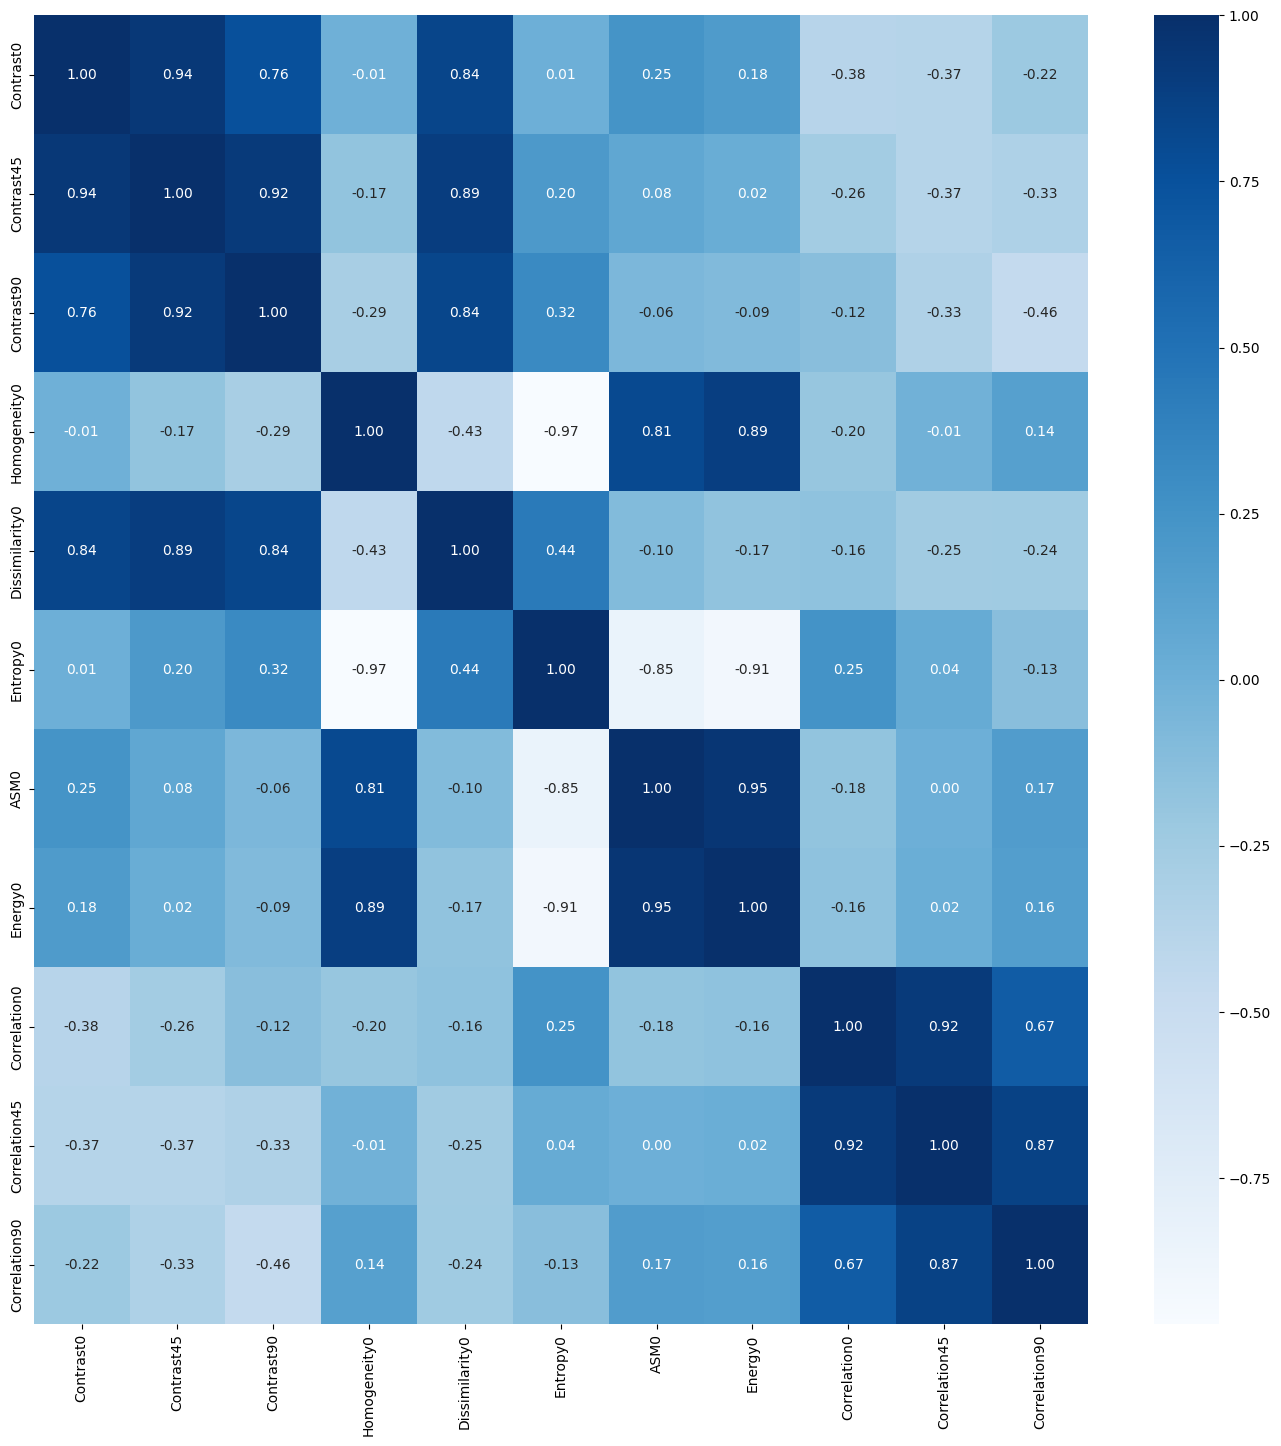

In [25]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [26]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(X_test.shape)

(147, 11)
(49, 11)


In [27]:
# normalisasi mean std (Standardization / Z-score normalization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [28]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [29]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        72
       tumor       1.00      1.00      1.00        75

    accuracy                           1.00       147
   macro avg       1.00      1.00      1.00       147
weighted avg       1.00      1.00      1.00       147

[[72  0]
 [ 0 75]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      normal       0.78      0.54      0.64        26
       tumor       0.61      0.83      0.70        23

    accuracy                           0.67        49
   macro avg       0.70      0.68      0.67        49
weighted avg       0.70      0.67      0.67        49

[[14 12]
 [ 4 19]]
Accuracy: 0.673469387755102


In [30]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      normal       0.78      0.72      0.75        72
       tumor       0.75      0.80      0.77        75

    accuracy                           0.76       147
   macro avg       0.76      0.76      0.76       147
weighted avg       0.76      0.76      0.76       147

[[52 20]
 [15 60]]
Accuracy: 0.7619047619047619

------Testing Set------
              precision    recall  f1-score   support

      normal       0.67      0.54      0.60        26
       tumor       0.57      0.70      0.63        23

    accuracy                           0.61        49
   macro avg       0.62      0.62      0.61        49
weighted avg       0.62      0.61      0.61        49

[[14 12]
 [ 7 16]]
Accuracy: 0.6122448979591837


In [31]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      normal       0.76      0.72      0.74        72
       tumor       0.75      0.79      0.77        75

    accuracy                           0.76       147
   macro avg       0.76      0.75      0.75       147
weighted avg       0.76      0.76      0.75       147

[[52 20]
 [16 59]]
Accuracy: 0.7551020408163265

------Testing Set------
              precision    recall  f1-score   support

      normal       0.79      0.42      0.55        26
       tumor       0.57      0.87      0.69        23

    accuracy                           0.63        49
   macro avg       0.68      0.65      0.62        49
weighted avg       0.69      0.63      0.62        49

[[11 15]
 [ 3 20]]
Accuracy: 0.6326530612244898


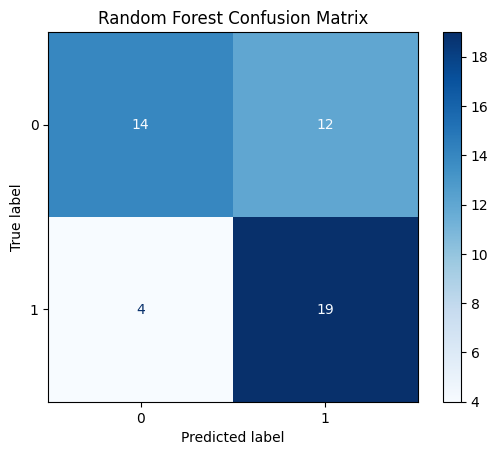

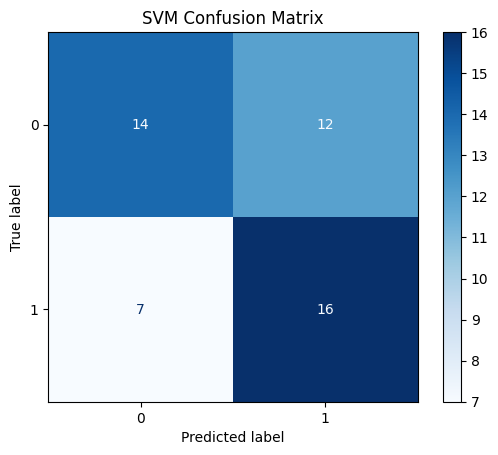

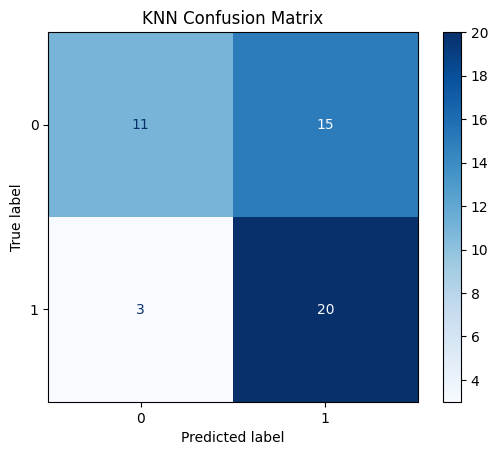

In [32]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

In [33]:
# ==========================
# TABEL PERBANDINGAN MODEL
# ==========================

hasil = []

models = {
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn
}

for nama, model in models.items():
    y_pred = model.predict(X_test)

    hasil.append([
        nama,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])

df_hasil = pd.DataFrame(
    hasil,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print("TABEL PERBANDINGAN MODEL")
display(df_hasil.round(6))



TABEL PERBANDINGAN MODEL


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.673469,0.700388,0.673469,0.667972
1,SVM,0.612245,0.621963,0.612245,0.610627
2,KNN,0.632653,0.685131,0.632653,0.615552
